In [4]:
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
def plot_cache(pth):
    df=pd.read_csv(pth)
    x=df['Size(Kb)'].to_list()
    col=df.columns.to_list()[1:]
    for i in col:
        plt.plot(x,df[i], marker='o',label=i)
    plt.xscale("log", base=2)   
    plt.xlabel("Cache Size (KB, log scale)")
    plt.ylabel("Miss Rate")
    plt.title("Cache Miss Rate vs Cache Size for Different Associativities")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

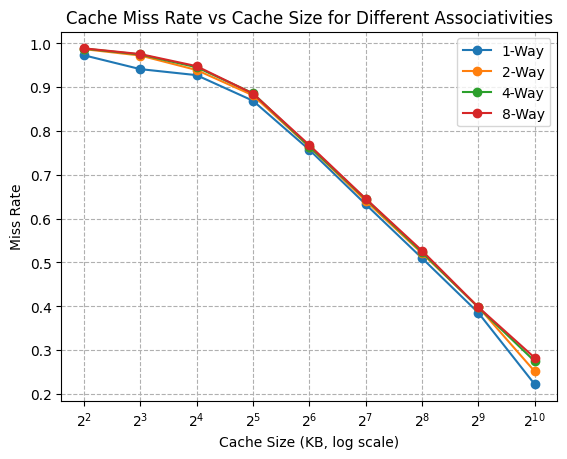

In [54]:
# L2 RISC Timing
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/l2_risc_tim.csv')

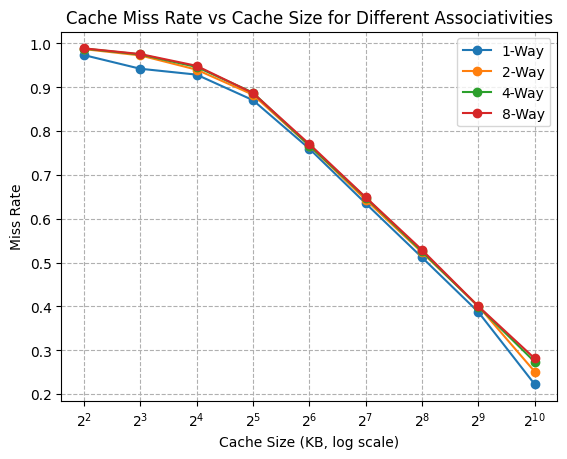

In [55]:
# L2 O3
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/l2_o3.csv')

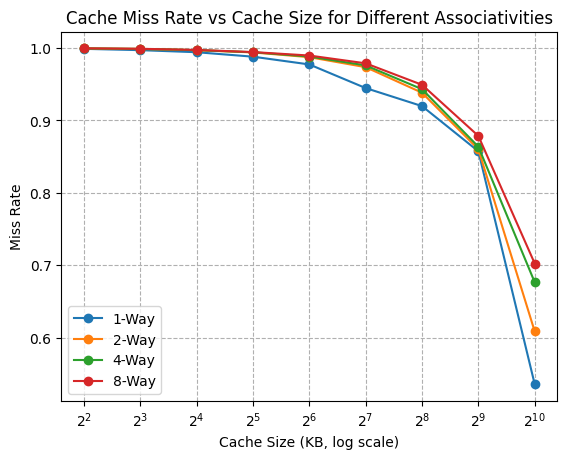

In [56]:
# L3 RISC Timing
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/l3_risc_tim.csv')

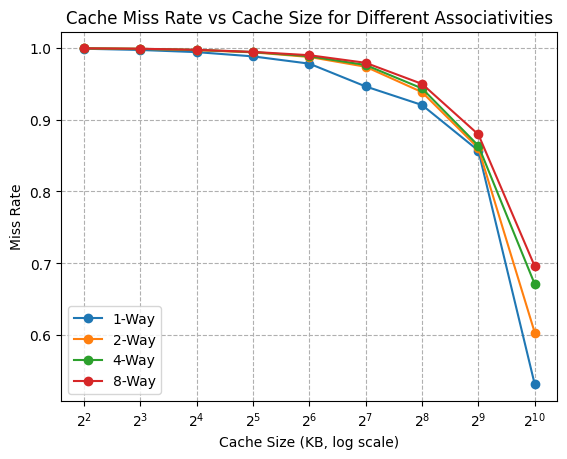

In [57]:
# L3 o3
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/l3_o3.csv')

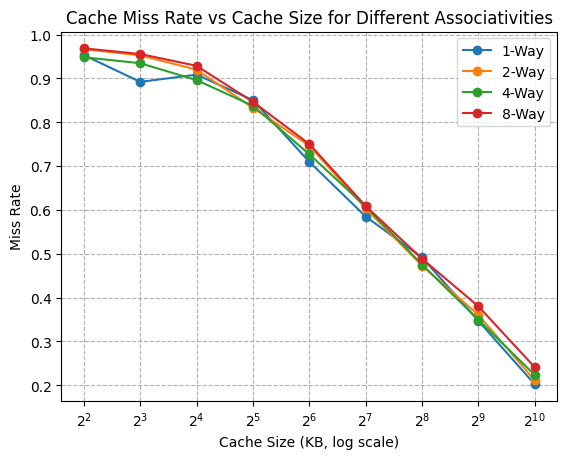

In [6]:
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/Modified_Miss_Rate_Table.csv')

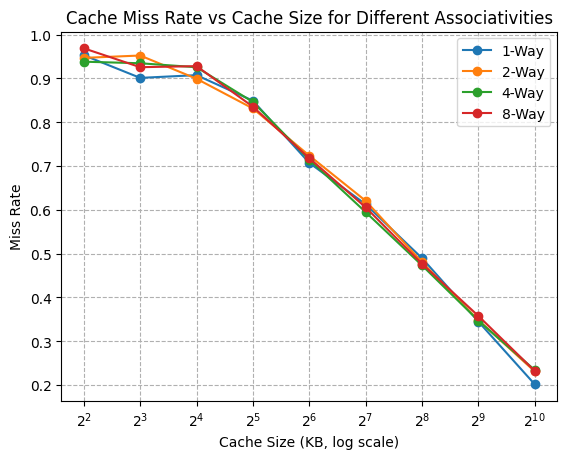

In [7]:
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/Modified_Miss_Rate_Table__Decremented_l2risc.csv')

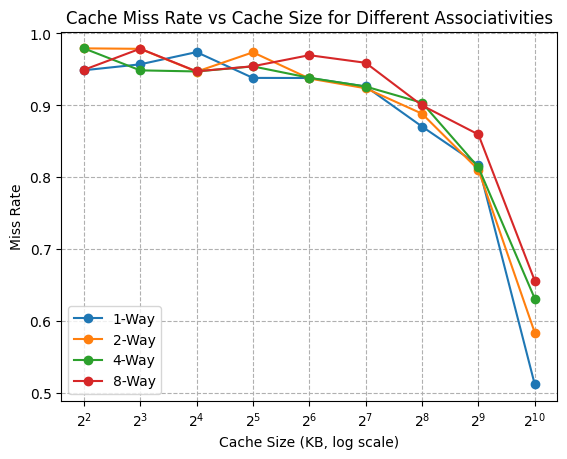

In [8]:
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/Modified_Miss_Rate_Table__Decremented_l3o3.csv')

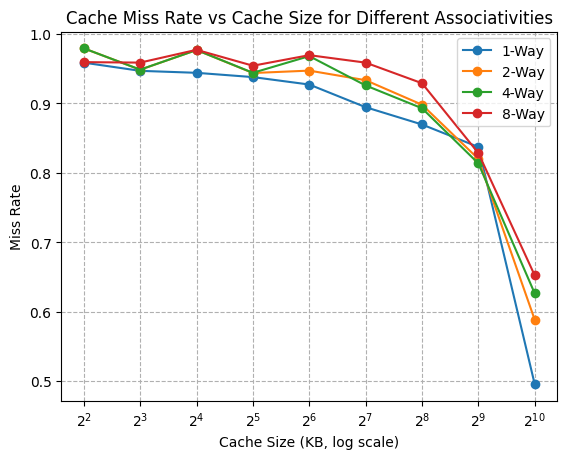

In [9]:
plot_cache('/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/Modified_Miss_Rate_Table__Decremented_l3risc.csv')

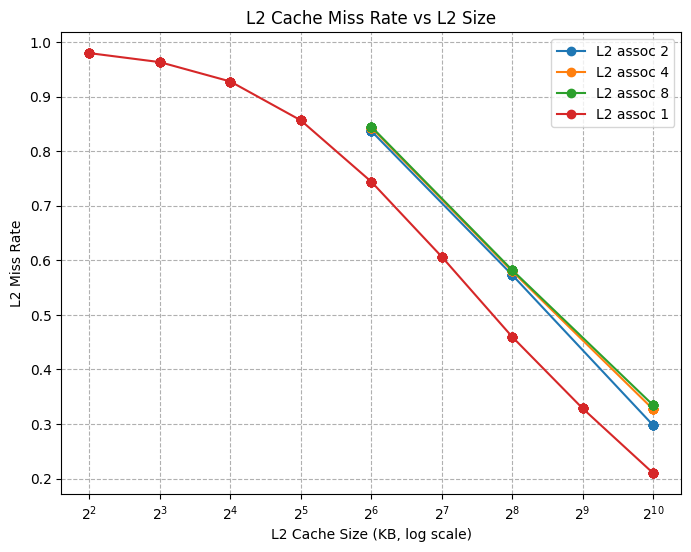

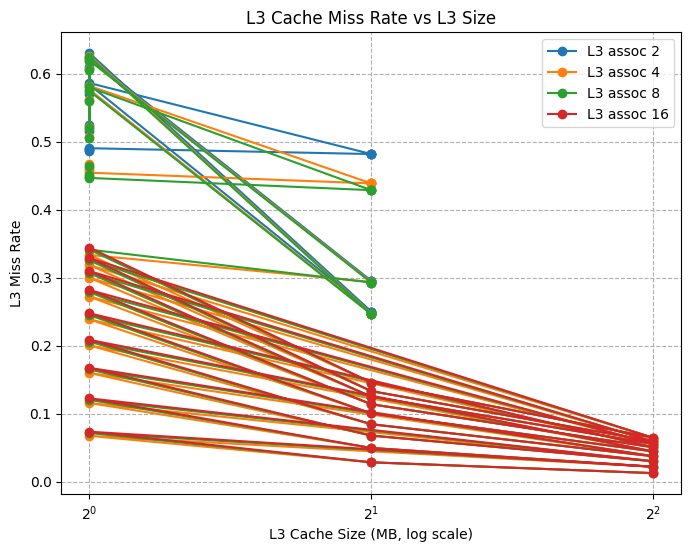

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV (replace with your file path if needed)
df = pd.read_csv("/Users/nishchal_mac/Downloads/Nishchal_2022330_CA_Assignment01/res.csv")

# --- Convert sizes to numeric KB/MB ---
def size_to_kb(size_str):
    if size_str.endswith("KiB"):
        return int(size_str.replace("KiB", ""))
    elif size_str.endswith("MiB"):
        return int(size_str.replace("MiB", "")) * 1024
    return int(size_str)

def size_to_mb(size_str):
    if size_str.endswith("MiB"):
        return int(size_str.replace("MiB", ""))
    elif size_str.endswith("KiB"):
        return int(size_str.replace("KiB", "")) // 1024
    return int(size_str)

df["L2_size_kB"] = df["l2_size"].apply(size_to_kb)
df["L3_size_MB"] = df["l3_size"].apply(size_to_mb)

# --- Plot L2 miss rate vs L2 size ---
plt.figure(figsize=(8,6))
for assoc in df["l2_assoc"].unique():
    subset = df[df["l2_assoc"] == assoc]
    plt.plot(subset["L2_size_kB"], subset["l2_missrate"], marker='o', label=f"L2 assoc {assoc}")

plt.xscale("log", base=2)
plt.xlabel("L2 Cache Size (KB, log scale)")
plt.ylabel("L2 Miss Rate")
plt.title("L2 Cache Miss Rate vs L2 Size")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# --- Plot L3 miss rate vs L3 size ---
plt.figure(figsize=(8,6))
for assoc in df["l3_assoc"].unique():
    subset = df[df["l3_assoc"] == assoc]
    plt.plot(subset["L3_size_MB"], subset["l3_missrate"], marker='o', label=f"L3 assoc {assoc}")

plt.xscale("log", base=2)
plt.xlabel("L3 Cache Size (MB, log scale)")
plt.ylabel("L3 Miss Rate")
plt.title("L3 Cache Miss Rate vs L3 Size")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()
